# Task 1

In [26]:
# 1. Firstly, we need to import libruaries:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 2. load data
data = {'Price': [300000, 450000, 600000], 'Area': [1200, 1800, 2400]}
df = pd.DataFrame(data)

# 3. devide in x, and y. Why those parameters
x = df[['Area']]
y = df['Price']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# 4. fit a model
model = LinearRegression()
model.fit(x_train, y_train)

# 5. Predictions
y_pred = model.predict(x)

# 6. Model evaluation
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"MSE: {mse:.3f}")
print(f"R-squared: {r2:.2f}")
print(f"Intercept: {model.intercept_:.3f}")
print(f"Coefficient: {model.coef_[0]:.3f}")


MSE: 0.000
R-squared: 1.00
Intercept: 0.000
Coefficient: 250.000


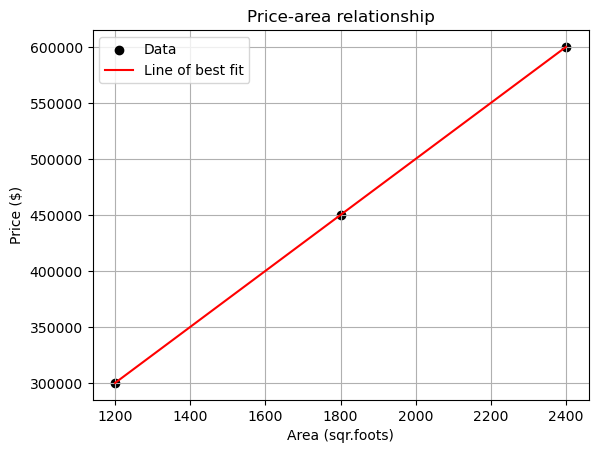

In [25]:
# Graph for task 1

plt.scatter(df['Area'], df['Price'], color='black', label='Data')
plt.plot(df['Area'], y_pred, color='red', label='Line of best fit')
plt.xlabel('Area (sqr.foots)')
plt.ylabel('Price ($)')
plt.title('Price-area relationship')
plt.legend()
plt.grid(True)
plt.show()

# Task 2

Intercept: -0.42
Coefficients: [2.49999306e+02 4.16665509e-01 2.88620637e-11]
MSE: 1.1293772630057337e-21
R^2: 1.00
MAE: 0.00
MAPE: 0.00
Predicted price is  499999.86111149687


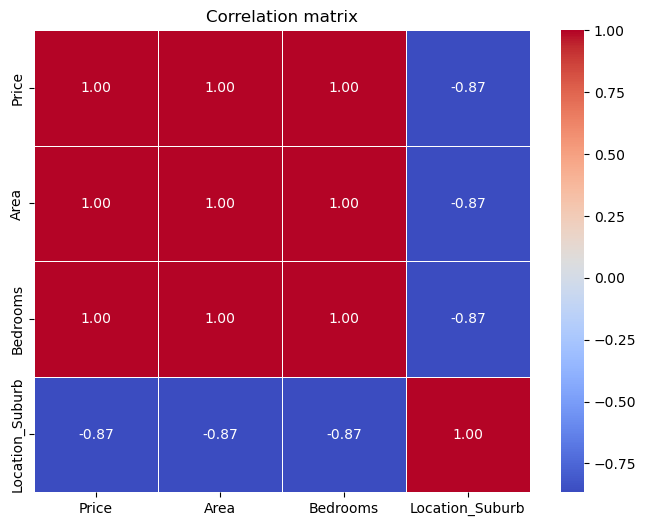

In [16]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import math

# 2 
data = {"Price": [300000, 450000, 600000],
        "Area": [1200, 1800, 2400],
        "Bedrooms": [3, 4, 5],
        "Location": ["Suburb", "City", "City"]}
df = pd.DataFrame(data)

# 3. one-hot encoding, 1 - city, 0 - suburb
df = pd.get_dummies(df, columns=["Location"], drop_first=True)

# 4.
X = df.drop(columns=["Price"])
y = df["Price"]

# 5. 
model = LinearRegression()
model.fit(X, y)


# 6.
print(f"Intercept: {model.intercept_:.2f}")
print(f"Coefficients: {model.coef_}")
y_pred = model.predict(X)

mse = mean_squared_error(y, y_pred)
print("MSE:", mse)

r2 = r2_score(y, y_pred)
print(f"R^2: {r2:.2f}")

mae = mean_absolute_error(y, y_pred)
print(f"MAE: {mae:.2f}")

mape = np.mean(np.abs((y - y_pred) / y)) * 100
print(f"MAPE: {mape:.2f}")




# Point to be predicted
new_house = pd.DataFrame([[2000, 4, 0]], columns=["Area", "Bedrooms", "Location_City"])
new_house = pd.get_dummies(new_house, columns=["Location_City"], drop_first=True)
print("Predicted price is ", predicted_price[0])

import seaborn as sns
import matplotlib.pyplot as plt
corr_matrix = df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation matrix")
plt.show()


# Task 3

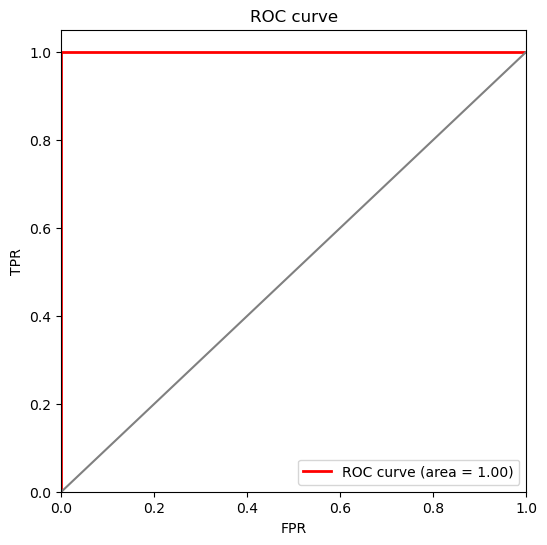

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc


data = { "Age": [30, 45, 25, 35, 50, 40, 28, 38, 29, 42, 33, 47, 55],
         "Salary": [40000, 60000, 30000, 50000, 70000, 55000, 32000, 48000, 35000, 62000, 41000, 75000, 80000],
         "Churn": [1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0]}
df = pd.DataFrame(data)


X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1] 


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = auc(*roc_curve(y_test, y_prob)[:2])



fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='red', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='-')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC curve')
plt.legend()
plt.show()
